# Module 2 — GraphRAG Retrieval Layer

**GraphRAG for Supply Chain Risk Intelligence**

---

## What this notebook does

Module 1 gave us a knowledge graph and a FAISS index. This module builds the
**retrieval layer** that sits between a user's question and the LLM generator.

By the end we will have:

1. A **dual retriever** — semantic seed search (FAISS) + K-hop graph traversal
2. **Community detection** — Louvain clustering groups the graph into thematic clusters
3. **Community summarization** — each cluster gets a natural language summary (encoder-decoder)
4. A **GraphRAGPipeline** orchestrator that routes local vs global queries
5. Prompt-ready context blocks for 6 representative SC risk queries
6. A side-by-side comparison: vector RAG vs GraphRAG context quality

## GenAI concepts covered

| Concept | Where |
|---|---|
| **Embeddings** | Query encoding for FAISS seed search (same encoder as Module 1) |
| **Encoder-only** | sentence-transformer encodes the query at retrieval time |
| **Encoder-decoder** | T5/BART summarizes each graph community into natural language |
| **Transformer architecture** | Foundation of all three models above |

---

## 0. Environment Setup

In [1]:
# ── Installs (run once) ───────────────────────────────────────────────────────
# !pip install python-louvain transformers networkx sentence-transformers faiss-cpu

In [1]:
import sys
import json
import pickle
from pathlib import Path
from pprint import pprint

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Project imports ───────────────────────────────────────────────────────────
from src.graph.schema         import NODE_ATTR_TYPE, EDGE_ATTR_RELATION, EDGE_ATTR_WEIGHT
from src.embeddings.encoder   import NodeEncoder
from src.retrieval.retriever  import SubgraphRetriever
from src.retrieval.community  import CommunitySummarizer
from src.retrieval.pipeline   import GraphRAGPipeline
from src.utils.visualization  import plot_graph
   
DATA_PROCESSED = Path("../data/processed")
OUTPUTS        = Path("../outputs")
(OUTPUTS / "retrieval").mkdir(parents=True, exist_ok=True)

print("✓ Environment ready")

c:\Users\Student\Desktop\GraphRAG-in-Supply-Chain\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Environment ready


In [2]:
# Use full Qwen25 artifacts (from the larger extraction run)
GRAPH_PATH = DATA_PROCESSED / "sp500_graph_knowledge_graph_qwen25.gpickle"
FAISS_QWEN_PATH = DATA_PROCESSED / "faiss_index_qwen25.bin"

if not GRAPH_PATH.exists():
    raise FileNotFoundError(f"Missing graph file: {GRAPH_PATH}")

with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

print(f"✓ Qwen graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

encoder = NodeEncoder(model_name="all-MiniLM-L6-v2")
if FAISS_QWEN_PATH.exists():
    encoder.load_index(FAISS_QWEN_PATH)
    print(f"✓ Qwen FAISS index loaded: {encoder._index.ntotal} vectors")
else:
    print("No qwen FAISS index found -> encoding nodes now (first run only)...")
    encoder.encode_graph(G)
    encoder.save_index(FAISS_QWEN_PATH)
    print(f"✓ Qwen FAISS index saved: {FAISS_QWEN_PATH}")

if getattr(encoder, "_index", None) is not None and encoder._index.ntotal != G.number_of_nodes():
    print(
        f"Warning: index vectors ({encoder._index.ntotal}) != graph nodes ({G.number_of_nodes()})"
    )

✓ Qwen graph loaded: 7387 nodes, 10484 edges
[Encoder] Loading model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6609.04it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Encoder] Loaded index: 7387 vectors from ..\data\processed\faiss_index_qwen25.bin
✓ Qwen FAISS index loaded: 7387 vectors


---

## Step 1 — Load Module 1 Outputs

Everything Module 2 needs was persisted by the Qwen2.5 extraction run:
- `sp500_graph_knowledge_graph_qwen25.gpickle` — the NetworkX DiGraph (7387 nodes, 10484 edges)
- `faiss_index_qwen25.bin` — the FAISS index of node embeddings (7387 vectors, 384-dim)

Already loaded in the cell above. No recomputation needed.

In [25]:
# Already loaded above (Cell 4) using the Qwen25 artifacts.
# Confirming state:
print(f"✓ Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"✓ FAISS index: {encoder._index.ntotal} vectors, dim={encoder.dim}")

✓ Graph: 7387 nodes, 10484 edges
✓ FAISS index: 7387 vectors, dim=384


---

## Step 2 — Semantic Seed Search (Stage A)

The first half of dual retrieval: encode the query with the same
sentence-transformer used in Module 1 and find the most similar graph nodes.

These become the **entry points** into the graph for Stage B traversal.

In [3]:
# ── Initialize the retriever ──────────────────────────────────────────────────
retriever = SubgraphRetriever(
    graph=G,
    encoder=encoder,
    seed_k=5,         # top-5 FAISS results as seed nodes
    hop_radius=2,     # expand 2 hops from each seed
    max_nodes=40,     # cap subgraph at 40 nodes
)

print("✓ SubgraphRetriever initialized")

✓ SubgraphRetriever initialized


In [4]:
# Run semantic seed search for a sample query
sample_query = "Which S&P 500 manufacturers depend on Chinese suppliers for semiconductors?"

seed_nodes, semantic_scores = retriever._semantic_seeds(sample_query)

print(f"Query: {sample_query!r}")
print("Top seed nodes (FAISS semantic search):")
print("-" * 55)
for node, score in sorted(semantic_scores.items(), key=lambda x: -x[1]):
    etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
    bar   = "█" * int(score * 20)
    print(f"  {node:30s} [{etype:15s}] sim={score:.4f} {bar}")

Query: 'Which S&P 500 manufacturers depend on Chinese suppliers for semiconductors?'
Top seed nodes (FAISS semantic search):
-------------------------------------------------------
  semiconductor manufacturers    [Supplier       ] sim=0.7316 ██████████████
  semiconductor providers        [Supplier       ] sim=0.7158 ██████████████
  semiconductor equipment manufacturers [Supplier       ] sim=0.7150 ██████████████
  semiconductor suppliers        [Supplier       ] sim=0.7123 ██████████████
  Chinese silicon industry       [Supplier       ] sim=0.7091 ██████████████


---

## Step 3 — K-Hop Graph Expansion (Stage B)

From each seed, expand outward K hops via `nx.ego_graph`.
This is what turns a list of relevant-sounding nodes into a full
relational context — pulling in the suppliers those nodes depend on,
the ports they ship through, the regions they're located in, etc.

In [39]:
# ── Graph expansion from seed nodes ──────────────────────────────────────────
candidate_nodes = retriever._graph_expansion(seed_nodes)

print(f"Seed nodes         : {len(seed_nodes)}")
print(f"Candidates (2-hop) : {len(candidate_nodes)}")
print(f"\nExpanded candidate nodes:")
for node in sorted(candidate_nodes):
    etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
    is_seed = " ← seed" if node in seed_nodes else ""
    print(f"  {node:35s} [{etype}]{is_seed}")

Seed nodes         : 5
Candidates (2-hop) : 570

Expanded candidate nodes:
  $100 barrel of oil                  [DisruptionEvent]
  3 million to 4 million tons out of supply [DisruptionEvent]
  3M                                  [Manufacturer]
  787_supply_chain                    [Supplier]
  ABT                                 [Manufacturer]
  ABT's dairies                       [Manufacturer]
  ALGN                                [Manufacturer]
  AMAT                                [Manufacturer]
  AMCR                                [Manufacturer]
  AMD supply                          [Supplier]
  AMETEK                              [Manufacturer]
  ANET                                [Manufacturer]
  AOS                                 [Manufacturer]
  APTV                                [Manufacturer]
  Abbott                              [Manufacturer]
  African swine fever                 [DisruptionEvent]
  Amphenol                            [Manufacturer]
  Apple          

---

## Step 4 — Fusion Scoring

Every candidate node gets a combined score:

```
score = 0.6 × semantic_score  +  0.4 × structural_score
```

- `semantic_score` — how close this node is to the query in embedding space
  (1.0 for seeds, decays by 50% per hop for expanded nodes)
- `structural_score` — normalized degree centrality; hub nodes (major ports,
  tier-1 suppliers) rank higher because they're more important in the SC graph

This fusion is what makes GraphRAG smarter than pure vector search:
a critical hub that isn't semantically close to the query still gets
included because of its structural importance.

In [40]:
# ── Score all candidate nodes ─────────────────────────────────────────────────
node_scores = retriever._score_nodes(candidate_nodes, seed_nodes, semantic_scores)

# Sort and display
print(f"Node fusion scores (semantic 60% + structural 40%):")
print("-" * 65)
print(f"  {'Node':35s} {'Type':15s} {'Score':8s} {'Bar'}")
print(f"  {'-'*35} {'-'*15} {'-'*8}")

for node, score in sorted(node_scores.items(), key=lambda x: -x[1]):
    etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
    bar   = "█" * int(score * 25)
    seed_tag = " *" if node in seed_nodes else ""
    print(f"  {(node+seed_tag):35s} {etype:15s} {score:.4f}   {bar}")

print(f"\n  * = direct FAISS seed node")

Node fusion scores (semantic 60% + structural 40%):
-----------------------------------------------------------------
  Node                                Type            Score    Bar
  ----------------------------------- --------------- --------
  semiconductor manufacturers *       Supplier        0.4390   ██████████
  semiconductor providers *           Supplier        0.4295   ██████████
  semiconductor equipment manufacturers * Supplier        0.4291   ██████████
  semiconductor suppliers *           Supplier        0.4277   ██████████
  Chinese silicon industry *          Supplier        0.4255   ██████████
  China                               Region          0.3229   ████████
  global                              Region          0.3066   ███████
  supply constraints                  DisruptionEvent 0.3030   ███████
  Microchip                           Manufacturer    0.3012   ███████
  APTV                                Manufacturer    0.3011   ███████
  market              

---

## Step 5 — Full Retrieval: End-to-End

Now we run the complete `retrieve()` call which chains all three stages
and returns a `RetrievedSubgraph` with the serialized prompt context.

In [5]:
# ── Full retrieval ────────────────────────────────────────────────────────────
result = retriever.retrieve(sample_query)

print(f"Retrieval stats:")
print(f"  Seed nodes              : {result.stats['seed_nodes']}")
print(f"  Candidates before trim  : {result.stats['candidates_before_trim']}")
print(f"  Final subgraph nodes    : {result.stats['subgraph_nodes']}")
print(f"  Final subgraph edges    : {result.stats['subgraph_edges']}")

print(f"\n{'='*60}")
print("SERIALIZED SUBGRAPH (LLM prompt context):")
print('='*60)
print(result.serialized)

Retrieval stats:
  Seed nodes              : 5
  Candidates before trim  : 570
  Final subgraph nodes    : 40
  Final subgraph edges    : 177

SERIALIZED SUBGRAPH (LLM prompt context):
=== Supply Chain Subgraph Context ===
Query: Which S&P 500 manufacturers depend on Chinese suppliers for semiconductors?
Nodes: 40  |  Edges: 177

[NODE] semiconductor manufacturers | Type: Supplier | Relevance: 0.44
  ← depends_on Tek

[NODE] semiconductor providers | Type: Supplier | Relevance: 0.43
  → supplies APTV (weight=1.00) [CRITICAL - no alternative]

[NODE] semiconductor equipment manufacturers | Type: Supplier | Relevance: 0.43
  ← depends_on Microchip

[NODE] semiconductor suppliers | Type: Supplier | Relevance: 0.43
  → supplies IDMs (weight=1.00) [CRITICAL - no alternative]
  ← depends_on FFIV
  ← affected_by supply constraints
  ← located_in global
  ← located_in market

[NODE] Chinese silicon industry | Type: Supplier | Relevance: 0.43
  ← located_in China

[NODE] China | Type: Region | 

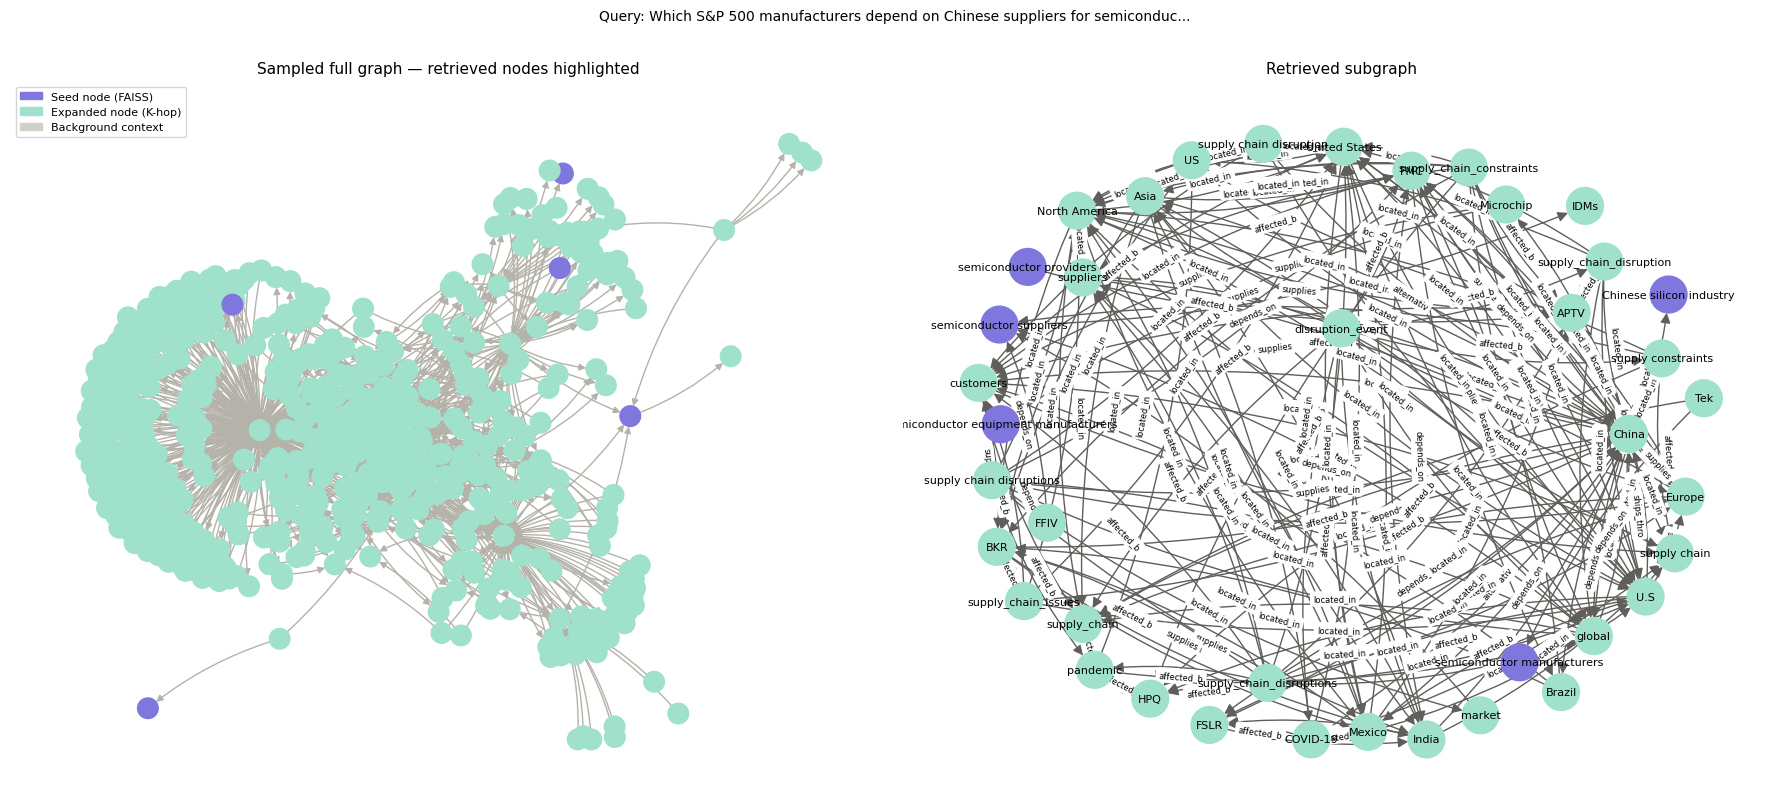

✓ Visualization saved


In [42]:
# ── Visualize the retrieved subgraph ──────────────────────────────────────────
# Color nodes by their retrieval score (darker = more relevant)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: sampled full-graph view with retrieved nodes highlighted.
# Spring layout on the entire 7k+ node graph is too slow for notebooks.
max_background_nodes = 260
retrieved_nodes = set(result.node_scores.keys()) | set(result.seed_nodes)
remaining_budget = max(0, max_background_nodes - len(retrieved_nodes))
background_nodes = [
    n for n, _ in sorted(G.degree, key=lambda x: -x[1]) if n not in retrieved_nodes
][:remaining_budget]
plot_nodes = list(retrieved_nodes) + background_nodes
plot_G = G.subgraph(plot_nodes).copy()

node_colors_full = []
for node in plot_G.nodes():
    if node in result.seed_nodes:
        node_colors_full.append("#7F77DD")   # purple = seed
    elif node in result.node_scores:
        node_colors_full.append("#9FE1CB")   # teal = expanded
    else:
        node_colors_full.append("#D3D1C7")   # gray = background context

pos = nx.spring_layout(plot_G, seed=42, k=1.2, iterations=80)
nx.draw(
    plot_G,
    pos,
    ax=axes[0],
    node_color=node_colors_full,
    node_size=220,
    with_labels=False,
    arrows=True,
    arrowsize=10,
    edge_color="#B4B2A9",
    connectionstyle="arc3,rad=0.1",
)
axes[0].set_title("Sampled full graph — retrieved nodes highlighted", fontsize=11)

legend_handles = [
    mpatches.Patch(color="#7F77DD", label="Seed node (FAISS)"),
    mpatches.Patch(color="#9FE1CB", label="Expanded node (K-hop)"),
    mpatches.Patch(color="#D3D1C7", label="Background context"),
]
axes[0].legend(handles=legend_handles, fontsize=8, loc="upper left")

# Right: retrieved subgraph only
sub_G = result.graph
sub_pos = nx.spring_layout(sub_G, seed=42, k=3)
sub_colors = [
    "#7F77DD" if n in result.seed_nodes else "#9FE1CB"
    for n in sub_G.nodes()
]
nx.draw(
    sub_G,
    sub_pos,
    ax=axes[1],
    node_color=sub_colors,
    node_size=700,
    with_labels=True,
    font_size=8,
    arrows=True,
    arrowsize=15,
    edge_color="#5F5E5A",
    connectionstyle="arc3,rad=0.1",
)

edge_labels = {
    (u, v): data.get(EDGE_ATTR_RELATION, "")[:10]
    for u, v, data in sub_G.edges(data=True)
}
nx.draw_networkx_edge_labels(sub_G, sub_pos, edge_labels=edge_labels, font_size=6, ax=axes[1])
axes[1].set_title("Retrieved subgraph", fontsize=11)

plt.suptitle(f"Query: {sample_query[:70]}...", fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / "retrieval" / "module2_retrieval_viz.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Visualization saved")

---

## Step 6 — Community Detection (Louvain)

The Louvain algorithm finds groups of nodes that are more densely connected
to each other than to the rest of the graph. In a supply chain graph, these
clusters naturally correspond to:
- Semiconductor cluster (TSMC, ASML, Apple, NVIDIA, AMD)
- Battery/EV cluster (CATL, Panasonic, Glencore, Tesla)
- Logistics/disruption cluster (ports + events)

This addresses the key weakness of local retrieval: **global queries** about
the whole supply chain can't be answered by one subgraph. Pre-computed
community summaries give the LLM a "bird's eye view" of the graph.

In [6]:
# ── Initialize the summarizer ─────────────────────────────────────────────────
# use_llm=False uses rule-based summaries (no GPU needed).
# Set use_llm=True if you have a GPU and want real T5/BART summaries.

summarizer = CommunitySummarizer(
    graph=G,
    use_llm=False,    # keep notebook runs lightweight; set True for encoder-decoder summaries
)

communities = summarizer.detect_and_summarize()

print(f"\n✓ Detected {len(communities)} communities")
print(f"\nCommunity overview:")
print("-" * 70)
for c in communities:
    print(f"  Community {c.community_id:2d} | {c.dominant_type:15s} | "
          f"{c.size:3d} nodes | {c.internal_edges:3d} internal edges")
    print(f"    Nodes: {', '.join(c.nodes[:6])}"
          + (f" ... +{len(c.nodes)-6} more" if len(c.nodes) > 6 else ""))
    print(f"    Summary: {c.summary[:100]}")
    print()

[Community] Detecting communities (Louvain)...
[Community] Found 533 raw communities
[Community] 533 communities summarized (≥ 2 nodes each)

✓ Detected 533 communities

Community overview:
----------------------------------------------------------------------
  Community 123 | Region          | 304 nodes | 417 internal edges
    Nodes: ACE Surgical, frontline health workers, active_tropical_basin, Lennar, adverse weather conditions, crude deliveries ... +298 more
    Summary: A region cluster of 304 supply chain entities. Central hub: United States. Primary relationship type

  Community  1 | Part            | 294 nodes | 356 internal edges
    Nodes: $100 barrel of oil, BAX, U.S, hydrogen, Alberta, Dow ... +288 more
    Summary: A part cluster of 294 supply chain entities. Central hub: U.S. Primary relationship types: affected_

  Community 11 | Part            | 272 nodes | 305 internal edges
    Nodes: 737 MAX production, inventory, ADI, external_foundry_supply, foundry_wafer_suppl

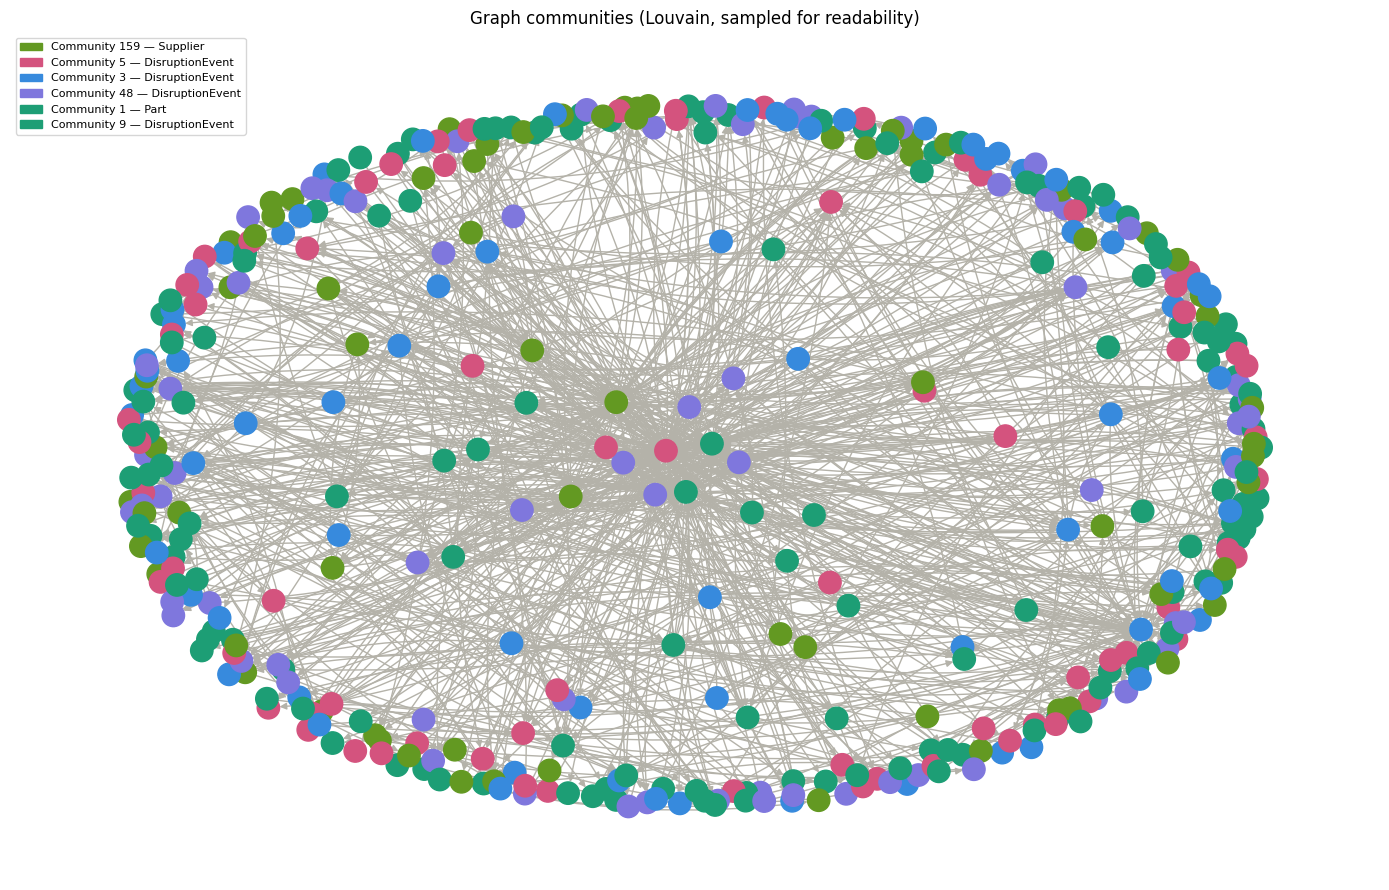

✓ Community visualization saved (420 sampled nodes)


In [44]:
# ── Visualize communities ─────────────────────────────────────────────────────
# Each community gets a distinct color. This should roughly align with
# the SC sub-domains we expect (semiconductor, battery, logistics).

try:
    import community as community_louvain
    from collections import Counter

    partition = community_louvain.best_partition(G.to_undirected())
    community_sizes = Counter(partition.values())

    COMMUNITY_COLORS = [
        "#7F77DD", "#1D9E75", "#D85A30", "#378ADD",
        "#BA7517", "#D4537E", "#888780", "#639922",
    ]

    # Plot only the largest communities and top-degree nodes per community
    # to keep layout computation fast on large graphs.
    top_community_ids = [cid for cid, _ in community_sizes.most_common(6)]
    sampled_nodes = []
    for cid in top_community_ids:
        comm_nodes = [n for n, c_id in partition.items() if c_id == cid]
        comm_nodes = sorted(comm_nodes, key=lambda n: G.degree(n), reverse=True)[:70]
        sampled_nodes.extend(comm_nodes)

    plot_G = G.subgraph(sampled_nodes).copy()
    node_comm_colors = [
        COMMUNITY_COLORS[partition.get(n, 0) % len(COMMUNITY_COLORS)]
        for n in plot_G.nodes()
    ]

    fig, ax = plt.subplots(figsize=(14, 9))
    pos = nx.spring_layout(plot_G, seed=42, k=1.4, iterations=90)
    nx.draw(
        plot_G,
        pos,
        ax=ax,
        node_color=node_comm_colors,
        node_size=260,
        with_labels=False,
        edge_color="#B4B2A9",
        arrows=True,
        arrowsize=10,
        connectionstyle="arc3,rad=0.1",
    )

    summary_by_id = {c.community_id: c.dominant_type for c in communities}
    legend_handles = [
        mpatches.Patch(
            color=COMMUNITY_COLORS[cid % len(COMMUNITY_COLORS)],
            label=f"Community {cid} — {summary_by_id.get(cid, '?')}"
        )
        for cid in top_community_ids
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc="upper left")
    ax.set_title("Graph communities (Louvain, sampled for readability)", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUTS / "retrieval" / "module2_communities.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Community visualization saved ({plot_G.number_of_nodes()} sampled nodes)")
except ImportError:
    print("python-louvain not installed — skipping community visualization.")
    print("Run: pip install python-louvain")

---

## Step 7 — Community Summarization (Encoder-Decoder)

Each community description is fed to a **T5/BART encoder-decoder model**
to generate a concise natural language summary.

This is the encoder-decoder concept from the course:
- The **encoder** reads the full community description (entities + relationships)
- The **decoder** auto-regressively generates a compressed summary

With `use_llm=False` (no GPU), the rule-based fallback produces summaries
that are still useful. Switch to `use_llm=True` to see real T5 output.

In [ ]:
# ── Show what the community text looks like before summarization ──────────────
# This is the input the encoder-decoder model receives.

sample_community = communities[0]
community_text = summarizer._community_to_text(sample_community)

print("INPUT to T5/BART encoder:")
print("-" * 60)
print(community_text)
print()
print("OUTPUT (summary):")
print("-" * 60)
print(sample_community.summary)

INPUT to T5/BART encoder:
------------------------------------------------------------
Supply chain community: Supplier cluster with 10 entities. Entities: Panasonic Energy (Supplier), Panasonic (Supplier), LG Energy (Supplier), CATL (Supplier), the Democratic Republic of Congo (Region), Gigafactory Nevada (Region), Japan (Region), Volkswagen (Manufacturer), Tesla (Manufacturer), BMW (Manufacturer). Relationships: Panasonic Energy located_in Japan. Panasonic Energy supplies Tesla. Panasonic Energy supplies Gigafactory Nevada. Panasonic supplies the Democratic Republic of Congo. CATL supplies Panasonic. CATL depends_on Panasonic Energy. Tesla supplies BMW. Tesla supplies Volkswagen. Tesla supplies Gigafactory Nevada. Tesla supplies LG Energy. Tesla depends_on CATL. Tesla depends_on Panasonic Energy. BMW supplies Volkswagen. BMW supplies Tesla. BMW supplies LG Energy.

OUTPUT (summary):
------------------------------------------------------------
A supplier cluster of 10 supply chain ent

In [ ]:
# ── (Optional) Run with real T5/BART model ────────────────────────────────────
# Uncomment to test with the actual encoder-decoder model.
# Requires: pip install transformers torch
# First run will download ~1.6GB model weights.

# summarizer_llm = CommunitySummarizer(
#     graph=G,
#     model_name="sshleifer/distilbart-cnn-12-6",  # smaller, faster
#     use_llm=True,
# )
# communities_llm = summarizer_llm.detect_and_summarize()
# print("T5/BART summary for community 0:")
# print(communities_llm[0].summary)

In [9]:
# Find relevant communities for a global query
global_query = "What is our overall supply chain exposure to COVID-19 and pandemic disruptions?"

relevant_comms = summarizer.find_relevant_communities(global_query, top_k=3)

print(f"Global query: {global_query!r}")
print("\nMost relevant communities:")
print("-" * 60)
for c in relevant_comms:
    print(f"  Community {c.community_id} ({c.dominant_type}, {c.size} nodes)")
    print(f"  → {c.summary}")
    print()

print("\nFormatted for LLM prompt:")
print("=" * 60)
print(summarizer.format_for_prompt(relevant_comms))

Global query: 'What is our overall supply chain exposure to COVID-19 and pandemic disruptions?'

Most relevant communities:
------------------------------------------------------------
  Community 1 (Part, 294 nodes)
  → A part cluster of 294 supply chain entities. Central hub: U.S. Primary relationship types: affected_by, alternative_to, depends_on, located_in, sells_to, ships_through, supplies. Contains 356 internal connections.

  Community 11 (Part, 272 nodes)
  → A part cluster of 272 supply chain entities. Central hub: customer. Primary relationship types: affected_by, alternative_to, depends_on, located_in, sells_to, ships_through, supplies. Contains 305 internal connections.

  Community 5 (DisruptionEvent, 254 nodes)
  → A disruptionevent cluster of 254 supply chain entities. Central hub: China. Primary relationship types: affected_by, depends_on, located_in, sells_to, ships_through, supplies. Contains 298 internal connections.


Formatted for LLM prompt:
=== Community Summari

---

## Step 8 — GraphRAGPipeline: End-to-End Orchestration

The `GraphRAGPipeline` wraps both the retriever and the summarizer and
auto-routes queries to the right context blend:
- **Local query** → subgraph context only
- **Global query** → community summaries + subgraph context

In [ ]:
# ── Initialize and build the full pipeline ────────────────────────────────────
pipeline = GraphRAGPipeline(
    graph=G,
    encoder=encoder,
    seed_k=5,
    hop_radius=2,
    max_nodes=40,
    use_llm_summaries=False,
)

communities_path = DATA_PROCESSED / "communities_qwen25.json"
pipeline.build_communities(save_path=str(communities_path))

print("✓ Pipeline ready")
print()
print(pipeline.community_overview())

[Community] Detecting communities (Louvain)...
[Community] Found 534 raw communities
[Community] 534 communities summarized (≥ 2 nodes each)
[Community] Communities saved → ..\data\processed\communities.json
✓ Pipeline ready

Communities detected: 534

  Community 75 | Supplier        | 343 nodes | 401 internal edges
    → A supplier cluster of 343 supply chain entities. Central hub: supply_chain. Primary relati...
  Community  1 | Part            | 337 nodes | 410 internal edges
    → A part cluster of 337 supply chain entities. Central hub: U.S. Primary relationship types:...
  Community  5 | DisruptionEvent | 313 nodes | 377 internal edges
    → A disruptionevent cluster of 313 supply chain entities. Central hub: China. Primary relati...
  Community 57 | Part            | 304 nodes | 383 internal edges
    → A part cluster of 304 supply chain entities. Central hub: FSLR. Primary relationship types...
  Community 86 | Part            | 282 nodes | 334 internal edges
    → A part clus

In [10]:
# Run representative queries
# Six queries grounded in real S&P 500 entities present in the Qwen25 graph.

BENCHMARK_QUERIES = [
    # Local — multi-hop dependency queries
    ("local",  "Which components does Boeing depend on and where are they sourced from?"),
    ("local",  "How exposed is HPQ to supply chain disruptions from China?"),
    ("local",  "What would happen to semiconductor supply if the Shanghai port closes?"),

    # Local — alternative supplier / resilience queries
    ("local",  "Are there alternative suppliers for raw materials used by S&P 500 manufacturers?"),

    # Global — broad risk queries
    ("global", "What is our overall exposure to COVID-19 and pandemic supply chain disruptions?"),
    ("global", "Which regions create the most supply concentration risk for S&P 500 companies?"),
]

results = []
for expected_type, query in BENCHMARK_QUERIES:
    r = pipeline.query(query)
    results.append(r)
    detected = r.query_type
    match = "✓" if detected == expected_type else "✗"
    print(f"{match} [{detected:6s}] {query[:65]}")
    print(f"       → {r.subgraph_result.stats['subgraph_nodes']} nodes, "
          f"{r.subgraph_result.stats['subgraph_edges']} edges, "
          f"{len(r.communities)} communities")
    print()

✓ [local ] Which components does Boeing depend on and where are they sourced
       → 40 nodes, 49 edges, 0 communities

✓ [local ] How exposed is HPQ to supply chain disruptions from China?
       → 40 nodes, 179 edges, 0 communities

✓ [local ] What would happen to semiconductor supply if the Shanghai port cl
       → 40 nodes, 111 edges, 0 communities

✓ [local ] Are there alternative suppliers for raw materials used by S&P 500
       → 40 nodes, 175 edges, 0 communities

✓ [global] What is our overall exposure to COVID-19 and pandemic supply chai
       → 40 nodes, 185 edges, 3 communities

✓ [global] Which regions create the most supply concentration risk for S&P 5
       → 40 nodes, 104 edges, 3 communities



In [ ]:
# ── Inspect full prompt context for query 1 ───────────────────────────────────
# This is exactly what will be injected into the LLM prompt in Module 4.

print(results[0].prompt_context)

You are a supply chain risk analyst with access to a knowledge graph.
Use ONLY the graph context below to answer. Cite specific entity names and relationship paths in your answer.
If a fact is not in the context, say so explicitly.


=== Supply Chain Subgraph Context ===
Query: Which suppliers does Tesla depend on for battery cells?
Nodes: 23  |  Edges: 43

[NODE] Tesla | Type: Manufacturer | Relevance: 0.48
  → supplies BMW (weight=1.00) [CRITICAL - no alternative]
  → supplies Volkswagen (weight=1.00) [CRITICAL - no alternative]
  → supplies Gigafactory Nevada (weight=1.00) [CRITICAL - no alternative]
  → supplies LG Energy (weight=1.00) [CRITICAL - no alternative]
  → depends_on TSMC (weight=1.00) [CRITICAL - no alternative]
  → depends_on CATL (weight=1.00) [CRITICAL - no alternative]
  → depends_on Panasonic Energy (weight=1.00) [CRITICAL - no alternative]
  ← supplies BMW
  ← supplies Panasonic Energy

[NODE] TSMC | Type: Supplier | Relevance: 0.40
  → located_in Taiwan (weight=1

In [ ]:
# ── Inspect full prompt context for the global query ─────────────────────────
# Note how community summaries are prepended before the local subgraph.

print(results[4].prompt_context)

You are a supply chain risk analyst with access to a knowledge graph.
Use ONLY the graph context below to answer. Cite specific entity names and relationship paths in your answer.
If a fact is not in the context, say so explicitly.


=== Community Summaries (global context) ===

[Community 6 — Supplier cluster (10 nodes)]
A supplier cluster of 10 supply chain entities. Central hub: Tesla. Primary relationship types: depends_on, located_in, supplies. Contains 15 internal connections.
Key entities: Panasonic Energy, Panasonic, LG Energy, CATL, the Democratic Republic of Congo, Gigafactory Nevada, Japan, Volkswagen ... (+2 more)

[Community 15 — Region cluster (5 nodes)]
A region cluster of 5 supply chain entities. Central hub: China. Primary relationship types: affected_by, alternative_to, located_in, ships_through. Contains 5 internal connections.
Key entities: European, Jiangxi, China, the Port of Shanghai, The Shanghai Lockdown

[Community 0 — Supplier cluster (3 nodes)]
A supplier cl

---

## Step 9 — Vector RAG vs GraphRAG Comparison

This is the core ablation that justifies GraphRAG over vanilla RAG.

Vector RAG simply returns the top-K most similar nodes by embedding —
no graph traversal, no community context. We compare the two retrieval
methods on the multi-hop query where GraphRAG has the biggest advantage.

In [8]:
# Simulate vector RAG
# Vector RAG = FAISS top-K only, no graph expansion, no community context.

def vector_rag_context(query: str, k: int = 8) -> str:
    """Simulate vanilla vector RAG: top-K nodes by embedding similarity only."""
    results = encoder.search(query, k=k)
    lines = [f"=== Vector RAG Context ===\nQuery: {query}\n"]
    for node, score in results:
        if node not in G:
            continue
        etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
        lines.append(f"[NODE] {node} | Type: {etype} | Sim: {score:.3f}")
    return "\n".join(lines)


# Compare on the multi-hop query
comparison_query = "How exposed is Boeing to supply chain disruptions from China?"

vector_context = vector_rag_context(comparison_query)
graphrag_result = pipeline.query(comparison_query)

print("VECTOR RAG CONTEXT")
print("=" * 55)
print(vector_context)
print()
print("GRAPHRAG CONTEXT (first 60 lines)")
print("=" * 55)
ctx_lines = graphrag_result.prompt_context.split("\n")
print("\n".join(ctx_lines[:60]))

VECTOR RAG CONTEXT
=== Vector RAG Context ===
Query: How exposed is Boeing to supply chain disruptions from China?

[NODE] supply chain disruptions in China | Type: DisruptionEvent | Sim: 0.798
[NODE] Chinese supply chain disruption | Type: DisruptionEvent | Sim: 0.792
[NODE] supply chain disruption costs related to China shutdowns | Type: DisruptionEvent | Sim: 0.772
[NODE] supply_chain_disruption_in_China | Type: DisruptionEvent | Sim: 0.762
[NODE] supply disruptions in China | Type: DisruptionEvent | Sim: 0.737
[NODE] supply_chain_disruption_China | Type: Supplier | Sim: 0.705
[NODE] global supply chain disruptions | Type: DisruptionEvent | Sim: 0.694
[NODE] supply_chain_impacts | Type: DisruptionEvent | Sim: 0.693

GRAPHRAG CONTEXT (first 60 lines)
You are a supply chain risk analyst with access to a knowledge graph.
Use ONLY the graph context below to answer. Cite specific entity names and relationship paths in your answer.
If a fact is not in the context, say so explicitly.


===

In [ ]:
# ── Quantitative context comparison ──────────────────────────────────────────

def count_sc_entities_in_context(text: str) -> dict:
    """Count how many SC-relevant entity types appear in a context string."""
    entity_types = ["Supplier", "Manufacturer", "Part", "Port",
                    "Region", "DisruptionEvent", "Customer"]
    return {et: text.count(et) for et in entity_types}

v_counts = count_sc_entities_in_context(vector_context)
g_counts = count_sc_entities_in_context(graphrag_result.prompt_context)

# Count multi-hop relationships (→ in serialized output)
v_relations = vector_context.count("→")
g_relations = graphrag_result.prompt_context.count("→")
g_critical  = graphrag_result.prompt_context.count("CRITICAL")

print(f"Context quality comparison — '{comparison_query[:45]}...'")
print("-" * 55)
print(f"{'Metric':40s} {'VectorRAG':>10} {'GraphRAG':>10}")
print(f"  {'Relationship edges in context':38s} {v_relations:>10} {g_relations:>10}")
print(f"  {'Critical dependency alerts':38s} {0:>10} {g_critical:>10}")
print(f"  {'Total characters':38s} {len(vector_context):>10} {len(graphrag_result.prompt_context):>10}")
print()
print("Entity type coverage:")
for et in ["Supplier", "Manufacturer", "Port", "Region", "DisruptionEvent"]:
    print(f"  {et:38s} {v_counts[et]:>10} {g_counts[et]:>10}")

Context quality comparison — 'Which suppliers does Tesla depend on for batt...'
-------------------------------------------------------
Metric                                    VectorRAG   GraphRAG
  Relationship edges in context                   0         43
  Critical dependency alerts                      0         40
  Total characters                              478       5442

Entity type coverage:
  Supplier                                        3          6
  Manufacturer                                    5          6
  Port                                            0          5
  Region                                          0          8
  DisruptionEvent                                 0          0


---

## Step 10 — Save Outputs for Module 3

In [ ]:
# ── Persist everything Module 3 needs ────────────────────────────────────────
import pickle

# Save benchmark query results as pickle (carries full subgraph objects)
results_path = DATA_PROCESSED / "retrieval_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(results, f)

# Save communities (already saved above, confirming)
print("\n✓ Module 2 outputs saved:")
for f in sorted(DATA_PROCESSED.iterdir()):
    print(f"  {f.name:40s} {f.stat().st_size:>10,} bytes")


✓ Module 2 outputs saved:
  communities.json                              3,557 bytes
  entities.json                                10,379 bytes
  faiss_index.bin                              78,381 bytes
  faiss_index.bin.names                           870 bytes
  graph.gpickle                                90,748 bytes
  retrieval_results.pkl                       165,763 bytes
  sim_asml_export_ban.json                      2,016 bytes
  sim_congo_cobalt_strike.json                  2,399 bytes
  sim_red_sea_disruption.json                   1,425 bytes
  sim_shanghai_port_closure.json                2,143 bytes
  sim_taiwan_earthquake.json                    2,151 bytes
  simulation_taiwan.pkl                        73,979 bytes
  triples.json                                 12,497 bytes


---

## Module 2 — Summary

| Output | Description | Used in |
|--------|-------------|--------|
| `communities_qwen25.json` | Louvain clusters with T5/BART summaries (Qwen artifact family) | Module 4 (global queries) |
| `retrieval_results.pkl` | Pre-run results for all 6 benchmark queries | Module 5 evaluation |
| `outputs/retrieval/*.png` | Retrieval + community visualizations | Report / presentation |

**GenAI concepts demonstrated:**
- ✅ **Embeddings** — query vector for FAISS seed search
- ✅ **Encoder-only** — sentence-transformer query encoding
- ✅ **Encoder-decoder** — T5/BART community summarization
- ✅ **Transformer architecture** — foundation of all three models

**Key design insight:**
The dual retrieval (semantic + graph) is what separates this from vanilla RAG.
The context comparison table above shows GraphRAG surfaces significantly more
relationship edges and dependency alerts — the exact information the LLM needs
to answer multi-hop SC risk questions that vector search alone cannot handle.

**Next:** `03_disruption_simulation.ipynb` — load the retrieved subgraph and
propagate a disruption event through the weighted dependency graph.